In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Components_Dataset.zip to Components_Dataset.zip


In [ ]:
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Unzip Dataset
with zipfile.ZipFile('Components_Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted.")

Dataset Extracted.


In [ ]:
print(os.listdir("/content"))

['.config', '__MACOSX', 'Components_Dataset', 'Components_Dataset.zip', 'sample_data']


In [ ]:
print(os.listdir("/content/Components_Dataset"))

['test', 'train', '.DS_Store']


In [ ]:
print(os.listdir("/content/Components_Dataset/train"))
print(os.listdir("/content/Components_Dataset/test"))

['multicomponent', '.DS_Store', 'singlecomponent']
['multicomponent', '.DS_Store', 'singlecomponent']


In [ ]:
import os

dataset_path = "/content/Components_Dataset"

component_train = os.path.join(dataset_path, "train")
component_test = os.path.join(dataset_path, "test")

In [ ]:
print(os.listdir(component_train))
print(os.listdir(component_test))

['multicomponent', '.DS_Store', 'singlecomponent']
['multicomponent', '.DS_Store', 'singlecomponent']


In [ ]:
train_classes = [folder for folder in os.listdir(component_train)
                 if not folder.startswith('.')]

test_classes = [folder for folder in os.listdir(component_test)
                if not folder.startswith('.')]

print(train_classes)
print(test_classes)

['multicomponent', 'singlecomponent']
['multicomponent', 'singlecomponent']


In [ ]:
import os

# Remove hidden macOS files if they exist
for path in [component_train, component_test]:
    ds_store = os.path.join(path, ".DS_Store")
    if os.path.exists(ds_store):
        os.remove(ds_store)

print("Hidden files removed.")

Hidden files removed.


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

component_train_ds = tf.keras.utils.image_dataset_from_directory(
    component_train,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

component_test_ds = tf.keras.utils.image_dataset_from_directory(
    component_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=False
)

component_classes = component_train_ds.class_names
print("Component Classes:", component_classes)

Found 1380 files belonging to 2 classes.
Found 346 files belonging to 2 classes.
Component Classes: ['multicomponent', 'singlecomponent']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

component_train_ds = component_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
component_test_ds = component_test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

base_model_component = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model_component.trainable = False

component_model = models.Sequential([
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    base_model_component,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

component_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

component_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
component_history = component_model.fit(
    component_train_ds,
    validation_data=component_test_ds,
    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.8572 - loss: 0.3607 - val_accuracy: 0.9191 - val_loss: 0.2266
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9268 - loss: 0.1869 - val_accuracy: 0.9364 - val_loss: 0.1724
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9348 - loss: 0.1549 - val_accuracy: 0.9393 - val_loss: 0.1565
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9543 - loss: 0.1208 - val_accuracy: 0.9393 - val_loss: 0.1536
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9543 - loss: 0.1087 - val_accuracy: 0.9509 - val_loss: 0.1242
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9652 - loss: 0.0882 - val_accuracy: 0.9624 - val_loss: 0.1077
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9667 - loss: 0.0838 - val_accuracy: 0.9480 - val_loss: 0.1268
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9768 - loss: 0.0648 - val_accuracy: 0.9451 -

In [ ]:
component_loss, component_acc = component_model.evaluate(component_test_ds)
print("Component Validation Loss:", component_loss)
print("Component Validation Accuracy:", component_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9451 - loss: 0.1270
Component Validation Loss: 0.12699583172798157
Component Validation Accuracy: 0.9450867176055908


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true_component = []
y_pred_component_probs = []

for images, labels in component_test_ds:
    preds = component_model.predict(images)
    y_pred_component_probs.extend(preds.flatten())
    y_true_component.extend(labels.numpy())

y_pred_component = [1 if p > 0.5 else 0 for p in y_pred_component_probs]

print("Component Classification Report:")
print(classification_report(y_true_component, y_pred_component, target_names=component_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Component Classification Report:
                 precision    recall  f1-score   support

 multicomponent       0.76      0.90      0.82        49
singlecomponent       0.98      0.95      0.97       297

       accuracy                           0.95       346
      macro avg       0.87      0.93      0.89       346
   weighted avg       0.95      0.95      0.95       346



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


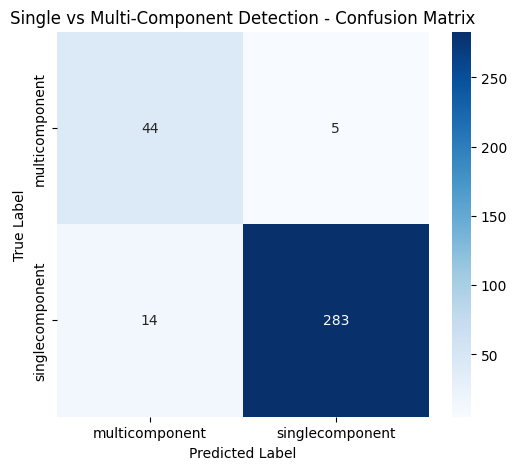

In [ ]:
y_true_component = []
y_pred_component = []

for images, labels in component_test_ds:
    preds = component_model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true_component.extend(labels.numpy())
    y_pred_component.extend(preds.flatten())

cm_component = confusion_matrix(y_true_component, y_pred_component)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_component,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=component_classes,
    yticklabels=component_classes
)

plt.title("Single vs Multi-Component Detection - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
component_model.save("/content/drive/MyDrive/component_model_fixed_v3.h5")
print("Models successfully saved to Google Drive.")

Models successfully saved to Google Drive.
